# Solve Maximum Weight Independent Set problems using Fire Opal
**Apply Fire Opal's built-in QAOA solver to Maximum Weight Independent Set problems**

The Maximum Weight Independent Set (MWIS) problem is a key combinatorial optimization problem with the objective to select a set of non-adjacent nodes in a graph such that the total weight of the selected nodes is maximized. It has broad applicability across diverse fields, such as vehicle routing, molecular structure analysis, resource allocation, and scheduling. An illustrative example of scheduling is our [recent work on rail scheduling](https://q-ctrl.com/case-study/accelerating-the-schedule-for-quantum-enhanced-rail), where we formulate the problem of assigning trains to optimal, conflict-free routes through stations in terms of MWIS.

[Fire Opal's built-in Quantum Approximate Optimization Algorithm (QAOA) solver](https://docs.q-ctrl.com/fire-opal/execute/run-algorithms/solve-optimization-problems/fire-opal-qaoa-solver) can deliver solutions to MWIS problem instances using quantum hardware.

Recently, [Q-CTRL published results](https://arxiv.org/abs/2406.01743) demonstrating Fire Opal's capability to correctly solve classically nontrivial unconstrained binary optimization problems at world-leading scale. Here, we show that Fire Opal can also be applied to problems involving constraints, which introduce additional complexity. Specifically, this application note covers the following:

- An introduction to MWIS
- An introduction to QAOA
- Execution of Fire Opal's QAOA solver for an 80-node, 3-regular weighted graph MWIS problem
- Evaluation of the QAOA solver performance

## 1. Introduction

### 1.1 Introduction to MWIS

An MWIS instance is defined by a graph with nodes that are assigned weights reflecting their importance or value. The goal is to determine a subset of nodes such that no two selected nodes share an edge, and the total weight of the selected nodes is maximized. MWIS generalizes the Maximum Independent Set problem, in which all nodes have equal weight and the objective is to find the largest independent subset.

Approximate and heuristic approaches for the MWIS problem are of particular interest as no algorithm is known that solves the MWIS problem exactly in polynomial time. In this context, near-term quantum computing presents a promising opportunity for efficiently generating high-quality approximate solutions for MWIS instances that are computationally challenging for classical methods.

### 1.2 Introduction to QAOA

QAOA is an algorithm often applied to combinatorial optimization problems, which involve finding an optimal object out of a finite set of objects. Such problems are relevant in many fields, such as portfolio optimization, supply chain optimization, optimal networking and scheduling, transportation routing, and more. Many combinatorial optimizations of interest fall under the NP-hard complexity class, meaning that there are no known polynomial-time solutions.

QAOA is one algorithm within the broader class of variational quantum algorithms (VQAs), which use classical optimization techniques to train a parameterized quantum circuit. Combining the power of both classical and quantum computation, VQAs are a promising method to achieve quantum advantage on NISQ devices and will likely remain relevant even in the age of fault-tolerant quantum computing.

Typically when implementing the QAOA, one must:
- Define cost and mixer Hamiltonians
- Construct circuits for the cost and mixer layers
- Choose parameters
- Prepare the initial state
- Implement a classical parameter optimizer

Adding to the challenge, most implementations of QAOA fail when executed on real hardware, either converging on the wrong solution or never converging at all.

Fire Opal’s QAOA solver alleviates the complexity of running QAOA algorithms by providing an easy-to-use function that consistently returns the correct answer. It converges quickly and enables the full QAOA implementation on problem sizes [greater than achievable with other commercial QAOA methods](https://arxiv.org/abs/2406.01743).

## 2. Imports and initializations

The following section sets up the necessary imports, credentials, and helper functions.

 Please note that you will need to additionally install a few additional packages such `qctrlvisualizer` and `PySCIPOpt` if you haven't done so already. You can install them via pip:

In [ ]:
%pip install qctrl-visualizer pyscipopt sympy networkx

In [3]:
import fireopal as fo
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from pyscipopt import Model
import qctrlvisualizer as qv
from sympy import Poly, symarray

plt.style.use(qv.get_qctrl_style())

### 2.1 Credentials and backend

We have developed this notebook to run on an IBM backend. To run it, you need an [IBM Quantum account](https://quantum.cloud.ibm.com/). Set up Fire Opal with your IBM account information and choose a backend.

In [ ]:
# Set credentials.
# The Fire Opal QAOA solver needs an IBM Cloud account with access to IBM Sessions execution mode,
# which is not available to Open Plan users. To use the solver, you must have a paid IBM Quantum plan.
# See here for details: https://quantum.cloud.ibm.com/docs/en/guides/execution-modes#session-mode
# and here for plans: https://www.ibm.com/quantum/products#access-plans
token = "YOUR_IBM_CLOUD_API_KEY"
instance = "YOUR_IBM_CRN"

credentials = fo.credentials.make_credentials_for_ibm_cloud(
    token=token, instance=instance
)

In [ ]:
# Enter your desired IBM backend here.
backend_name = "your_desired_backend"

### 2.2 Helper functions

Define functions that are used to set up the MWIS problem instance and analyze the results.

In [5]:
def mwis_to_cost(graph: nx.Graph) -> Poly:
    """
    Convert a graph representing a MWIS instance to a cost polynomial.
    """
    node_ids = {node: i for i, node in enumerate(graph.nodes)}
    variables = symarray("x", graph.number_of_nodes())
    # Set a conflict penalty high enough to discourage adjacent selections
    conflict_weight = 4 * max(graph.nodes[n]["weight"] for n in graph.nodes)

    cost = 0
    # Reward including a node
    for node in graph.nodes:
        cost -= graph.nodes[node]["weight"] * variables[node_ids[node]]
    # Penalize selecting adjacent nodes
    for u, v in graph.edges():
        cost += conflict_weight * variables[node_ids[u]] * variables[node_ids[v]]

    return Poly(cost, *variables)


def draw_graph(graph: nx.Graph, bitstring: str = "", index_map: dict = None) -> None:
    """
    Visualize an MWIS problem graph optionally highlighting selected nodes.
    If an index map is provided, bitstring indices are reordered accordingly.
    """
    # Identify selected nodes
    if index_map:
        solution = {
            str(index_map[key])
            for i, key in enumerate(index_map.keys())
            if bitstring[i] == "1"
        }
    else:
        solution = {str(i) for i, bit in enumerate(bitstring) if bit == "1"}
    # Assign node colors based on selection
    node_colors = [
        qv.QCTRL_STYLE_COLORS[0] if node in solution else qv.QCTRL_STYLE_COLORS[2]
        for node in graph.nodes
    ]
    # Use node weights as labels
    labels = nx.get_node_attributes(graph, "weight")
    pos = nx.spring_layout(graph, seed=0)
    nx.draw(
        graph,
        pos,
        with_labels=True,
        labels=labels,
        node_color=node_colors,
        font_color="white",
    )
    plt.show()


def solve_classically(graph: nx.Graph) -> tuple[str, float]:
    """
    Solve the MWIS problem classically using linear programming (SCIP).
    """
    model = Model("MWIS")
    model.hideOutput(True)
    # Create binary decision variables for each node
    x = {
        v: model.addVar(name=f"x_{v}", vtype="B", obj=graph.nodes[v]["weight"])
        for v in graph.nodes
    }
    # Add constraints
    for u, v in graph.edges():
        model.addCons(x[u] + x[v] <= 1)

    model.setMaximize()
    model.optimize()

    if model.getStatus() != "optimal":
        raise RuntimeError("Solver did not find an optimal solution.")

    solution = [v for v in graph.nodes if model.getVal(x[v]) > 0.5]
    solution_bitstring = "".join("1" if v in solution else "0" for v in graph.nodes)
    total_weight = sum(graph.nodes[v]["weight"] for v in solution)

    return solution_bitstring, total_weight


def check_independence(bitstring: str, graph: nx.Graph, index_map: dict = None) -> bool:
    """
    Check whether the selected nodes form an independent set in the problem graph.
    If an index map is provided, bitstring indices are reordered accordingly.
    """
    if index_map:
        selected_nodes = {
            str(index_map[key])
            for i, key in enumerate(index_map.keys())
            if bitstring[i] == "1"
        }
    else:
        selected_nodes = {str(i) for i, bit in enumerate(bitstring) if bit == "1"}
    for u, v in graph.edges:
        if u in selected_nodes and v in selected_nodes:
            return False
    return True


def get_cost_distribution(
    distribution: dict[str, int], cost: Poly, index_map: dict = None
) -> tuple[np.ndarray, np.ndarray]:
    """
    Given a bitstring count distribution and a cost polynomial, compute the costs and relative probabilities.
    If an index map is provided, bitstring indices are reordered accordingly.
    """
    shot_count = sum(distribution.values())
    variables = cost.gens
    costs = []
    probabilities = []
    # Calculate the cost and probability for each bitstring
    for bitstring, count in distribution.items():
        if index_map:
            costs.append(
                cost.subs({var: bitstring[index_map[str(var)]] for var in variables})
            )
        else:
            costs.append(cost.subs(zip(cost.gens, bitstring)))
        probabilities.append(count / shot_count)
    return np.array(costs), np.array(probabilities)


def generate_random_bitstrings(
    length: int, num_bitstrings: int, rng_seed: int = 0
) -> list[str]:
    """
    Generate a random sampling of bitstrings.
    """
    # Initialize the random number generator with a seed for reproducibility
    rng = np.random.default_rng(seed=rng_seed)
    # Generate random bitstrings
    random_array = rng.integers(0, 2, size=(num_bitstrings, length))
    bitstrings = ["".join(row.astype(str)) for row in random_array]
    return bitstrings


def analyze_mwis_results(
    distribution: dict[str, int],
    bitstring: str,
    graph: nx.graph,
    cost: Poly,
    index_map: dict,
) -> None:
    """
    Analyze and visualize results from a MWIS execution using Fire Opal.
    """
    best_weight = -cost.subs({var: bitstring[index_map[str(var)]] for var in cost.gens})
    print(f"The best solution found by Fire Opal has weight {best_weight}.")
    print(
        "The selected set is independent."
        if check_independence(bitstring, graph, index_map)
        else "The selected set includes conflicting nodes."
    )

    # Number of variables
    qubit_count = len(bitstring)
    # Total number of bitstrings (shots)
    shot_count = sum(distribution.values())

    # Get cost distribution from the results
    costs, probs = get_cost_distribution(distribution, cost, index_map)
    # Generate random bitstrings and get their cost distribution
    random_bitstrings = generate_random_bitstrings(qubit_count, shot_count)
    random_probs = np.ones(shot_count) / shot_count
    random_costs = np.asarray(
        [cost.subs(zip(cost.gens, bitstring)) for bitstring in random_bitstrings]
    )

    # Plot cost histograms
    _, ax = plt.subplots(1, 1)
    ax.hist(
        [-costs, -random_costs],
        np.arange(-2000, -min(costs) + 1, 20),
        weights=[probs, random_probs],
        label=["Fire Opal QAOA solver", "Random Sampling"],
        color=[qv.QCTRL_STYLE_COLORS[0], qv.QCTRL_STYLE_COLORS[1]],
    )
    ax.set_xlabel("Weight")
    ax.set_ylabel("Probability")
    ax.legend()

## 3. Example problem setup

As an example, we load a pre-generated MWIS problem instance: an 80-node 3-regular graph with random node weights ranging from 1 to 10. The problem graph is illustrated below, with node labels indicating weights. This example can be replaced with any user-defined MWIS problem. After loading the problem graph, we compute the corresponding cost polynomial.

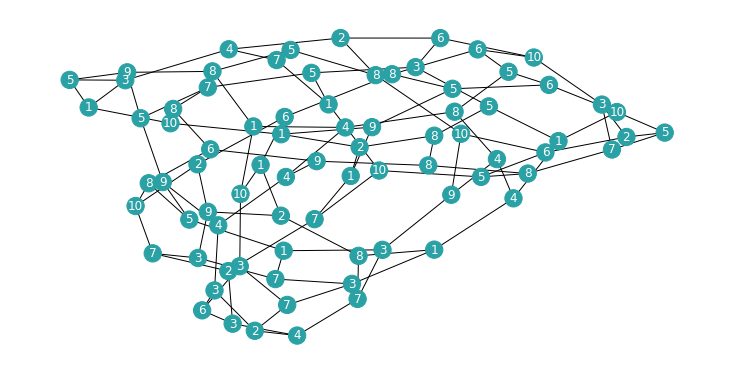

In [6]:
mwis = nx.read_graphml("resources/mwis.graphml")
draw_graph(mwis)

In [7]:
cost = mwis_to_cost(mwis)

## 4. Running the algorithm

Run Fire Opal's QAOA solver for the cost polynomial representing the MWIS problem.

In [ ]:
fire_opal_job = fo.solve_qaoa(cost, credentials, backend_name)

The following command extracts the Fire Opal result as soon as the calculation has finished. To check the current job status, you can run `fire_opal_job.status()`.

In [ ]:
fire_opal_solution = fire_opal_job.result()

## 5. Analyze Fire Opal output

To establish a performance baseline, we compare the cost distribution of Fire Opal's QAOA solver output to that of randomly sampled bitstrings. This comparison is particularly relevant as a naive QAOA implementation using standard Qiskit compiler settings typically yields results that are indistinguishable from random sampling at the considered problem scale. To ensure a fair comparison, the number of random samples matches the number of shots used for the QAOA circuits.

The best solution found by Fire Opal has weight 223.
The selected set is independent.


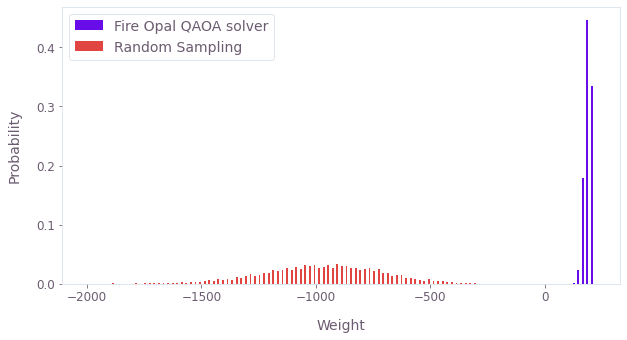

In [9]:
analyze_mwis_results(
    fire_opal_solution["final_bitstring_distribution"],
    fire_opal_solution["solution_bitstring"],
    mwis,
    cost,
    fire_opal_solution["variables_to_bitstring_index_map"],
)

Fire Opal clearly outperforms random sampling, consistently returning high-quality solutions, that is, independent sets with large total weight. The negative weights observed for random sampling indicate invalid solutions, where the selected nodes do not form an independent set.

Since the example problem is still solvable with classical methods, it is possible to assess the accuracy of the best solution obtained with Fire Opal.

In [9]:
optimal_solution, optimal_weight = solve_classically(mwis)
print(f"Optimal classical solution is an independent set with weight {optimal_weight}.")

Optimal classical solution is an independent set with weight 223.


The solution returned by Fire Opal is optimal. It corresponds to the MWIS illustrated below, with selected nodes highlighted in purple.

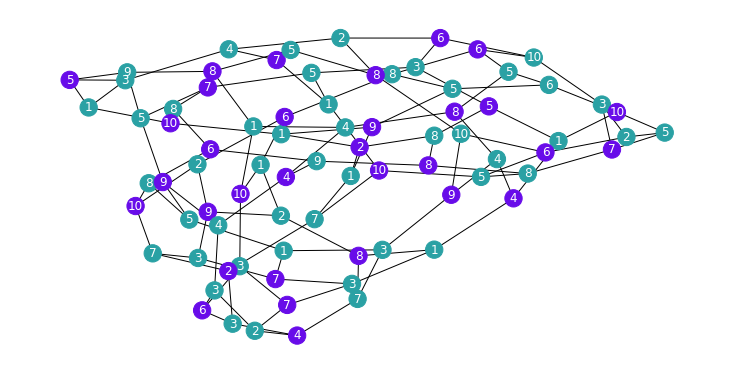

In [10]:
draw_graph(
    mwis,
    fire_opal_solution["solution_bitstring"],
    fire_opal_solution["variables_to_bitstring_index_map"],
)

You have successfully leveraged Fire Opal's QAOA Solver to solve a challenging MWIS problem with quantum hardware. For a deeper dive into what sets Fire Opal's QAOA Solver apart and its efficacy in finding accurate solutions at utility scales, explore the topic on [Fire Opal's QAOA Solver](https://docs.q-ctrl.com/fire-opal/execute/run-algorithms/solve-optimization-problems/fire-opal-qaoa-solver).

The following package versions were used to produce this notebook.

In [11]:
fo.print_package_versions()

| Package               | Version |
| --------------------- | ------- |
| Python                | 3.11.11 |
| matplotlib            | 3.10.1  |
| networkx              | 2.8.8   |
| numpy                 | 1.26.4  |
| sympy                 | 1.13.3  |
| fire-opal             | 8.4.1   |
| qctrl-visualizer      | 8.0.2   |
| qctrl-workflow-client | 5.5.0   |
